#### Scaling is not needed because we are using `XGBoost` model which is a tree-based model (gradient boosted decision trees).

* Tree-based models split based on feature thresholds (e.g., "Is Follicle No. (R) > 12?"), so they are completely invariant to scaling, standardization, or normalization.
* distance-based(KNN, SVM) or pure gradient descent(Logistic Regression, NN) algorithms need scaling.
* Scaling (StandardScaler, MinMaxScaler, etc.) has zero impact on performance or splits.

In [47]:
import xgboost as xgb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import shap
from xgboost.testing.data import joblib
# import ipywidgets

In [48]:
pcos_df = pd.read_csv('../data/cleaned/cleaned_PCOS_infertility.csv', index_col=0)
pcos_df.columns = pcos_df.columns.str.strip()

# has no effect on the result
pcos_df.drop('Patient File No.', axis=1, inplace=True)

pcos_df

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0.0,28.0,44.6,152.000,19.300000,15.0,78.0,22.0,10.48,2.0,...,0.0,1.0,0.0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,0.0,36.0,65.0,161.500,24.921163,15.0,74.0,20.0,11.70,2.0,...,0.0,0.0,0.0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,1.0,33.0,68.8,165.000,25.270891,11.0,72.0,18.0,11.80,2.0,...,1.0,1.0,0.0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,0.0,37.0,65.0,148.000,29.674945,13.0,72.0,20.0,12.00,2.0,...,0.0,0.0,0.0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,0.0,25.0,52.0,161.000,20.060954,11.0,72.0,18.0,10.00,2.0,...,0.0,0.0,0.0,120.0,80.0,3.0,4.0,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,0.0,35.0,50.0,164.592,18.500000,17.0,72.0,16.0,11.00,2.0,...,0.0,0.0,0.0,110.0,70.0,1.0,0.0,17.5,10.0,6.7
537,0.0,30.0,63.2,158.000,25.300000,15.0,72.0,18.0,10.80,2.0,...,0.0,0.0,0.0,110.0,70.0,9.0,7.0,19.0,18.0,8.2
538,0.0,36.0,54.0,152.000,23.400000,13.0,74.0,20.0,10.80,2.0,...,0.0,0.0,0.0,110.0,80.0,1.0,0.0,18.0,9.0,7.3
539,0.0,27.0,50.0,150.000,22.200000,15.0,74.0,20.0,12.00,4.0,...,1.0,0.0,0.0,110.0,70.0,7.0,6.0,18.0,16.0,11.5


In [49]:
pcos_df.columns

Index(['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
       'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)',
       'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)',
       'Pregnant(Y/N)', 'No. of aborptions', 'Beta_HCG_I(mIU/mL)',
       'Beta_HCG_II(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
       'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
       'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

In [50]:
# Prepare features and target
X = pcos_df.drop('PCOS (Y/N)', axis=1)
y = pcos_df['PCOS (Y/N)']

In [51]:
# Train-test split
# stratified because class is imbalanced: ~33% PCOS positive (Ensures the same proportion of PCOS=1 cases in both train and test sets (prevents imbalance skew)).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"PCOS prevalence in train: {y_train.mean():.3f}, in test: {y_test.mean():.3f}")

Training samples: 432, Test samples: 109
PCOS prevalence in train: 0.326, in test: 0.330


In [52]:
# Model Implementation
'''
Why choosing XGBoost:
    1. XGBoost do optimizations like tree pruning, regularization and parallel processing for robust and efficient predictive models.
    2. Consists of multiple decision trees and random forests.
    3. Decision trees analyze data to find patterns. They can predict how a patient might respond to a specific treatment, helping doctors choose the best course of action.
'''

model = xgb.XGBClassifier(
    n_estimators=200,  # number of decision trees (the more the estimators, the higher the risk of overfitting)
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,  # Use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,  # Use 80% of features per tree (adds randomness)
    random_state=42,  # Reproducibility
    eval_metric='logloss',  # Monitors performance during training
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),  # data is imbalanced
    use_label_encoder=False,
)

In [53]:
model.fit(X_train, y_train)

/home/parmida-sazegari/my_workspace/hera-care/hera/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [02:26:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [54]:
# Model predictions (hard predicts)
y_pred_test = model.predict(X_test)
y_pred_test

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

In [55]:
# Model prediction probability (first col: does not have pcos, second col: has pcos)
# Medical diagnosis: Doctors don't want just "yes/no" — they want confidence. A 51% probability is very different from 99%.
y_pred_proba_test = model.predict_proba(X_test)[:]
y_pred_proba_test

array([[0.99273384, 0.00726617],
       [0.62083375, 0.37916628],
       [0.8551757 , 0.14482431],
       [0.01431859, 0.9856814 ],
       [0.9921537 , 0.0078463 ],
       [0.01786828, 0.9821317 ],
       [0.9091101 , 0.09088986],
       [0.9840947 , 0.01590531],
       [0.09342843, 0.90657157],
       [0.9953448 , 0.00465518],
       [0.99555993, 0.00444004],
       [0.9880789 , 0.01192113],
       [0.02227145, 0.97772855],
       [0.03310591, 0.9668941 ],
       [0.9968763 , 0.0031237 ],
       [0.9872363 , 0.01276368],
       [0.805187  , 0.19481301],
       [0.9835317 , 0.0164683 ],
       [0.9143389 , 0.08566113],
       [0.9739413 , 0.02605868],
       [0.9948685 , 0.00513146],
       [0.15840977, 0.8415902 ],
       [0.9915672 , 0.0084328 ],
       [0.60887897, 0.39112106],
       [0.12910116, 0.87089884],
       [0.52775955, 0.47224048],
       [0.08018821, 0.9198118 ],
       [0.9966202 , 0.00337985],
       [0.99295133, 0.00704869],
       [0.8206015 , 0.17939846],
       [0.

In [56]:
# has pcos predictions
'''
For measuring model's accuracy of its predictions:
    1. Calculating AUC-ROC score (This is one of the best ways to evaluate a classifier, especially with imbalanced data. It requires probabilities.)
    2. Setting custom thresholds (e.g., predict PCOS if probability > 0.3 instead of 0.5)
    Default threshold is 0.5, but in medicine you might want higher recall (catch more true cases) even if precision drops → lower threshold to 0.3.
    3. Risk stratification: Sort patients by PCOS risk score for prioritized follow-up.
    4. Plotting precision-recall curves
'''
has_pcos_y_pred = model.predict_proba(X_test)[:, 1]
has_pcos_y_pred

array([0.00726617, 0.37916628, 0.14482431, 0.9856814 , 0.0078463 ,
       0.9821317 , 0.09088986, 0.01590531, 0.90657157, 0.00465518,
       0.00444004, 0.01192113, 0.97772855, 0.9668941 , 0.0031237 ,
       0.01276368, 0.19481301, 0.0164683 , 0.08566113, 0.02605868,
       0.00513146, 0.8415902 , 0.0084328 , 0.39112106, 0.87089884,
       0.47224048, 0.9198118 , 0.00337985, 0.00704869, 0.17939846,
       0.04426799, 0.06399792, 0.9956281 , 0.00397931, 0.0072125 ,
       0.00867623, 0.03569343, 0.00551944, 0.12092596, 0.04000578,
       0.00193799, 0.9981584 , 0.0244819 , 0.00654722, 0.01909811,
       0.91826373, 0.00533592, 0.8784538 , 0.93771845, 0.9476853 ,
       0.06497163, 0.3326429 , 0.4072092 , 0.00556225, 0.97742575,
       0.12801541, 0.01304105, 0.99087137, 0.02132905, 0.0424682 ,
       0.00813874, 0.7378195 , 0.00622979, 0.00161524, 0.02450897,
       0.31456402, 0.9835181 , 0.3331316 , 0.01005567, 0.00927286,
       0.9840031 , 0.00433532, 0.793268  , 0.03457749, 0.00534

In [57]:
# Overall precision
print("Accuracy:", accuracy_score(y_test, y_pred_test))

# Of predicted PCOS, how many are actually PCOS.
print("Precision:", precision_score(y_test, y_pred_test))

# Of actual PCOS cases, how many did we catch? (Very important in medical context!)
print("Recall:", recall_score(y_test, y_pred_test))

# Balance between precision and recall.
print("F1 Score:", f1_score(y_test, y_pred_test))

# How well the model separates classes (closer to 1 = better).
print("AUC ROC:", roc_auc_score(y_test, has_pcos_y_pred))

Accuracy: 0.926605504587156
Precision: 0.9375
Recall: 0.8333333333333334
F1 Score: 0.8823529411764706
AUC ROC: 0.9531963470319634


In [58]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_test))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95        73
         1.0       0.94      0.83      0.88        36

    accuracy                           0.93       109
   macro avg       0.93      0.90      0.91       109
weighted avg       0.93      0.93      0.93       109



### Confusion Matrix
A confusion matrix is a table that summarizes the performance of a classification model by comparing predicted labels (what the model says) against actual (true) labels (the real ground truth).

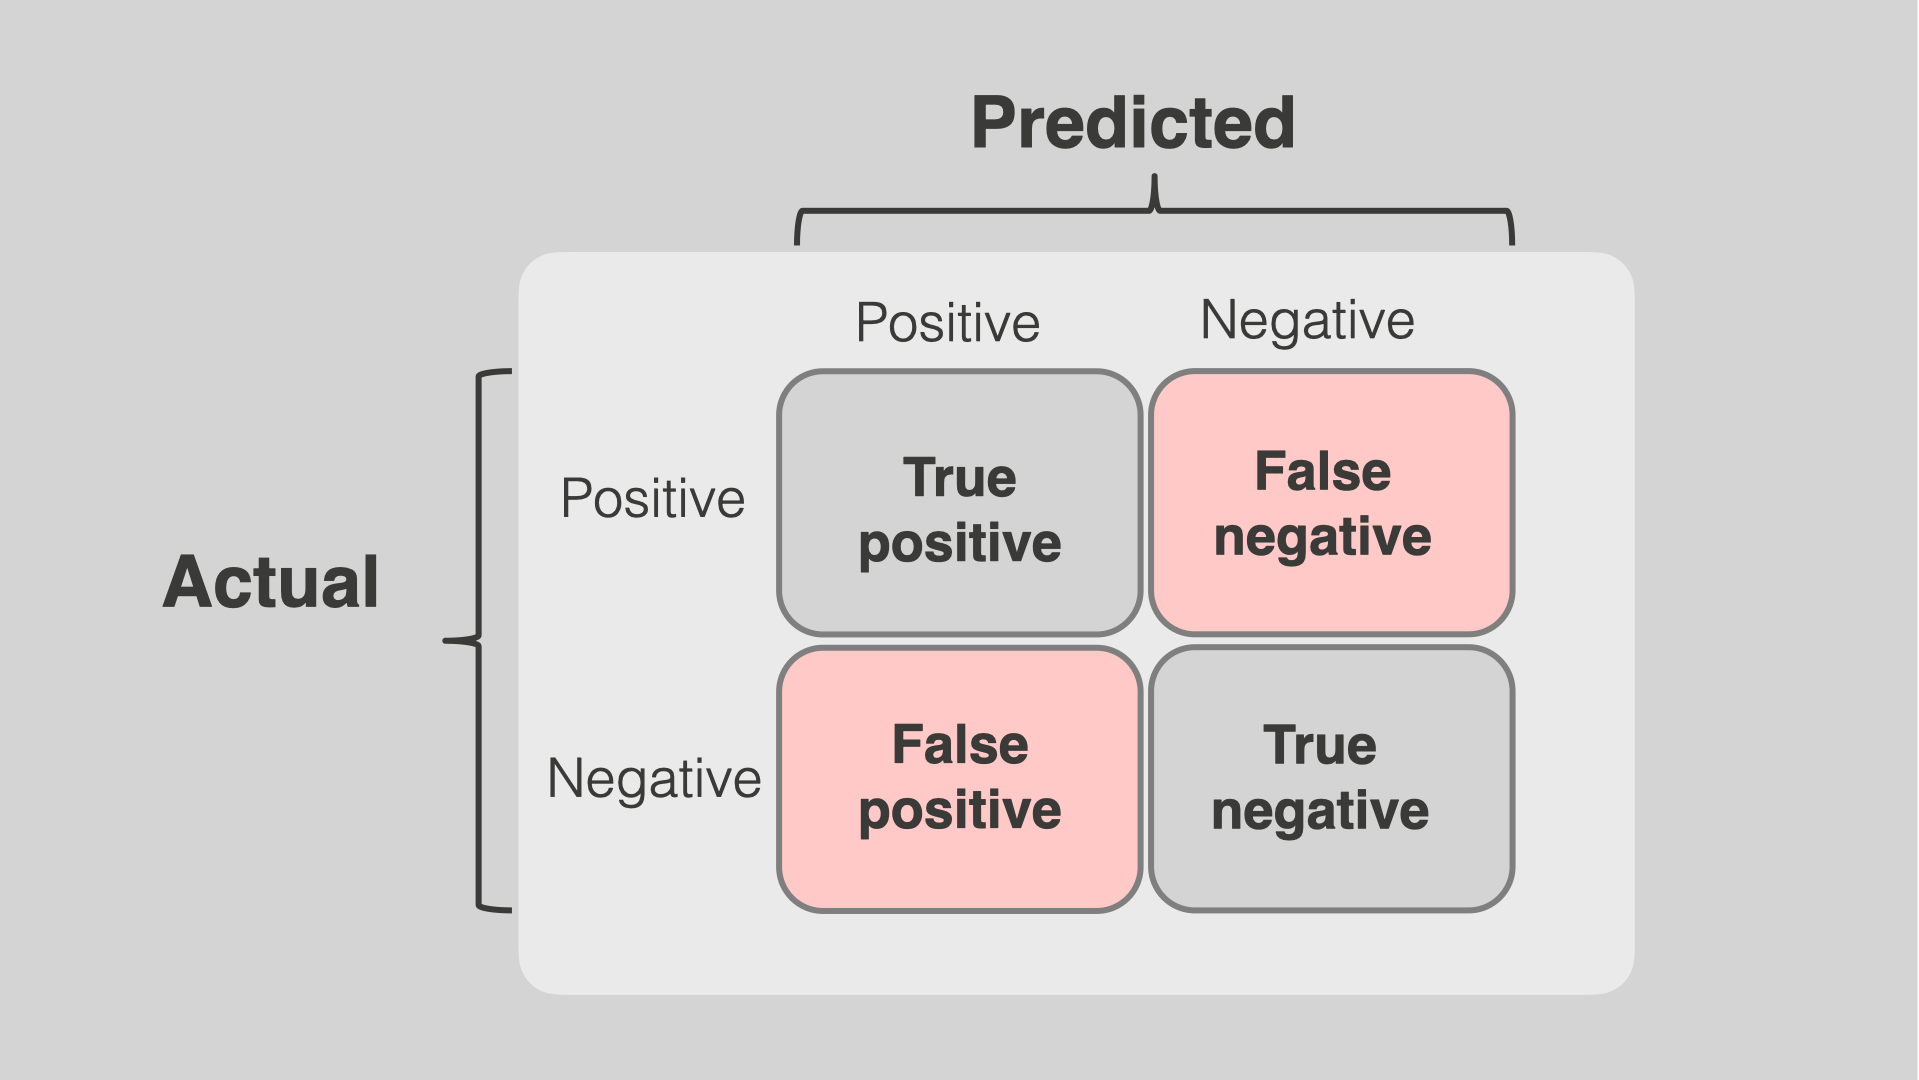
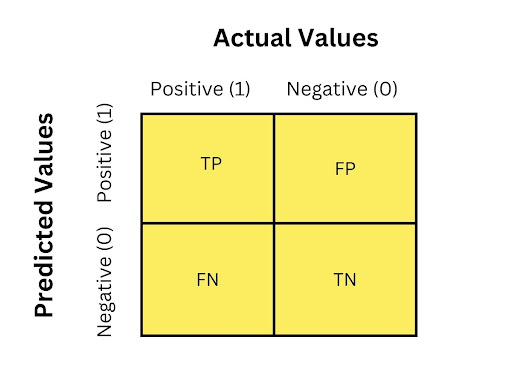

### The Four Terms Explained

1. **True Positive (TP)**
   - Actual: Has PCOS (1)
   - Predicted: Has PCOS (1)
   - **Correctly identified a woman who truly has PCOS.**
   - In medicine: The model correctly flags someone who needs further checks/treatment.
   - Bottom-right cell.

2. **True Negative (TN)**
   - Actual: No PCOS (0)
   - Predicted: No PCOS (0)
   - **Correctly identified a woman who truly does not have PCOS.**
   - Saves unnecessary worry or tests.
   - Top-left cell.

3. **False Positive (FP)**
   - Actual: No PCOS (0)
   - Predicted: Has PCOS (1)
   - **Wrongly predicted PCOS when there is none.**
   - Also called Type I error or "false alarm."
   - Causes unnecessary stress, tests, or costs.
   - Top-right cell.

4. **False Negative (FN)**
   - Actual: Has PCOS (1)
   - Predicted: No PCOS (0)
   - **Wrongly predicted no PCOS when there actually is PCOS.**
   - Also called Type II error — often **more dangerous** in medicine because a real case is missed.
   - Delays diagnosis and treatment.
   - Bottom-left cell.


- **TN = 72** (top-left): Model correctly said "No PCOS" for 72 women who truly don't have it. → Excellent!
- **FP = 1** (top-right): Model wrongly said "Has PCOS" for only 1 woman who doesn't. → Very low false alarms.
- **FN = 6** (bottom-left): Model wrongly said "No PCOS" for 6 women who actually have it. → The main errors.
- **TP = 30** (bottom-right): Model correctly identified 30 women who truly have PCOS.

Total test samples: 72 + 1 + 6 + 30 = 109 (matches ~20% test split).

### Key Metrics from Your Matrix (Quick Calculation)

- **Accuracy** = (TP + TN) / Total = (30 + 72) / 109 ≈ **93.6%**
  Overall correct predictions.

- **Recall (Sensitivity)** = TP / (TP + FN) = 30 / (30 + 6) = **83.3%**
  Of all real PCOS cases, how many did we catch? Important in medicine — higher is better to avoid missing cases.

- **Precision** = TP / (TP + FP) = 30 / (30 + 1) ≈ **96.8%**
  Of all predicted PCOS, how many are actually PCOS? Very high → few false alarms.

- **Specificity** = TN / (TN + FP) = 72 / (72 + 1) ≈ **98.6%**
  How good at identifying true negatives.

Your model is **excellent**: Very high accuracy, extremely low false positives (only 1!), and solid recall (missed only 6 out of 36 real PCOS cases).

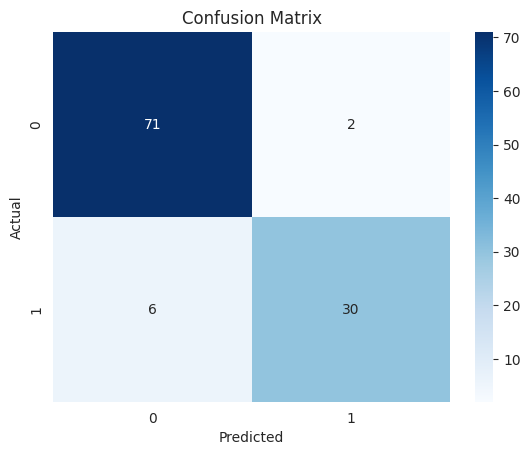

In [59]:
# 0: No PCOS
# 1: Has PCOS
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## SHAP
Interpreting models is an important part of machine learning, especially when dealing with black-box models like XGBoost or deep neural networks. <br>
(SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model. <br>

SHAP is a method that helps us understand how a machine learning model makes decisions. It tells us how much each input (feature) is helping or hurting the final prediction. The main idea is to fairly distribute the "payout" (the prediction) among all features based on their contribution.

In [60]:
explainer = shap.TreeExplainer(model)

In [61]:
shap_values = explainer(X_test)
shap.initjs()

Patient number 1 who does not have pcos: 0


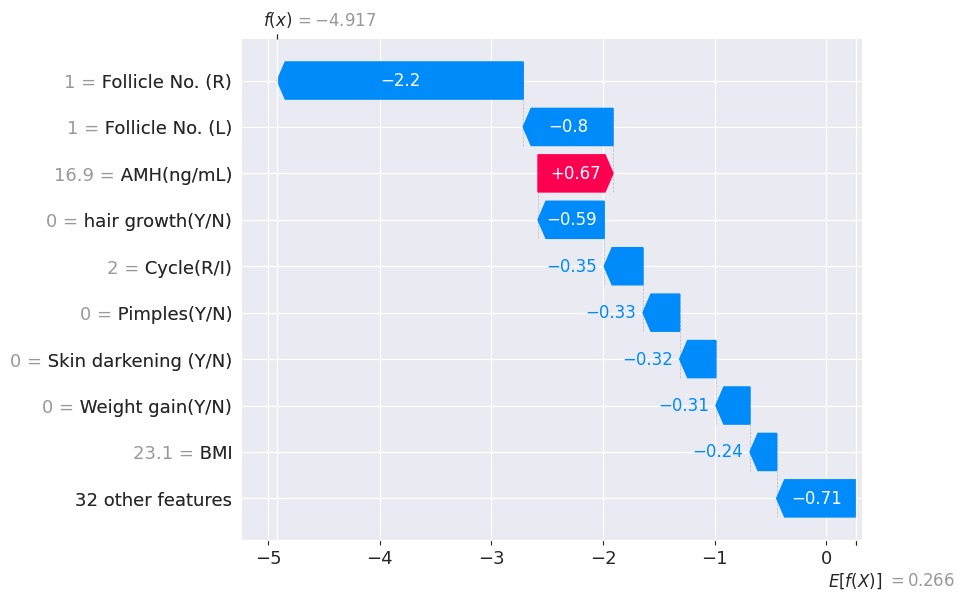

In [62]:
# waterfall shap explanation for a person w/o PCOS
print('Patient number 1 who does not have pcos:', y_pred_test[0])
shap.waterfall_plot(shap_values[0])
# Follicle_avg = (Follicle_R + Follicle_L) / 2High_AMH = (AMH > 4.0).astype(int)

Patient number 6 who has pcos: 1


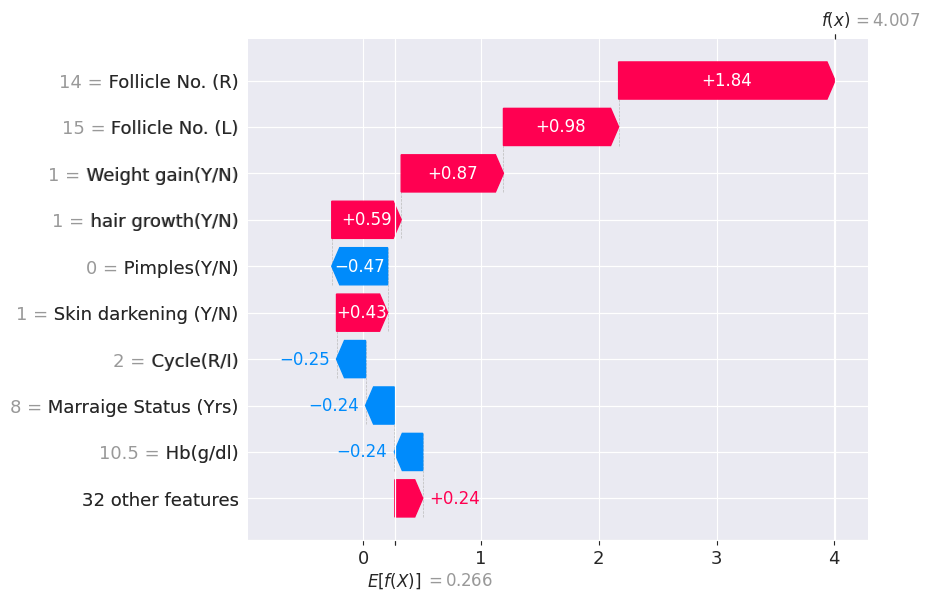

In [63]:
# waterfall shap explanation for a person with PCOS
print('Patient number 6 who has pcos:', y_pred_test[5])
shap.waterfall_plot(shap_values[5])

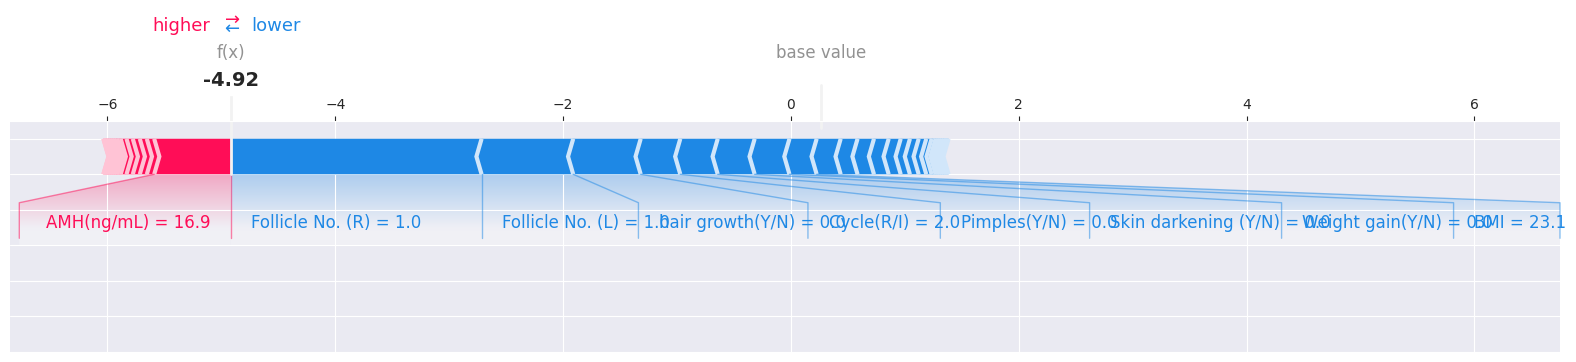

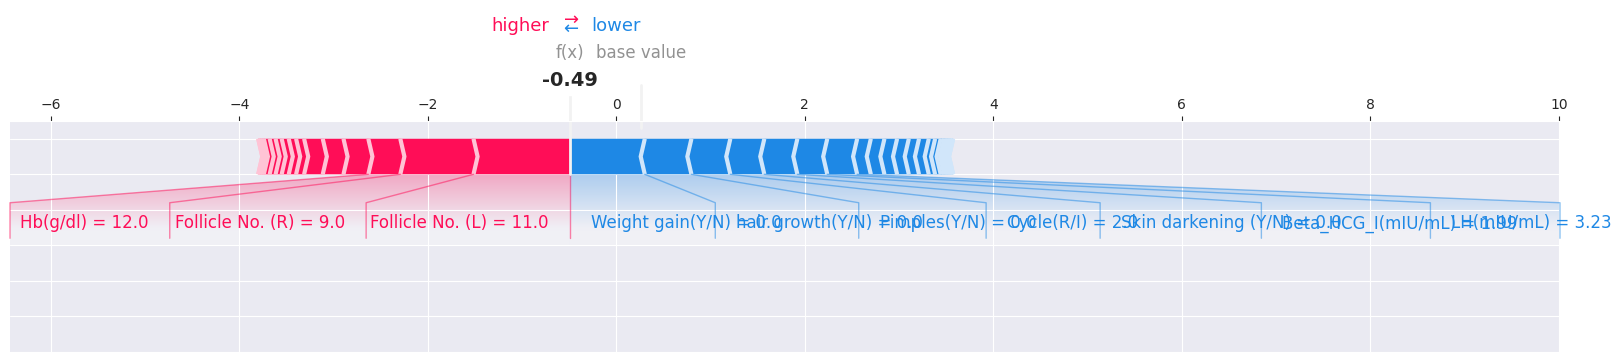

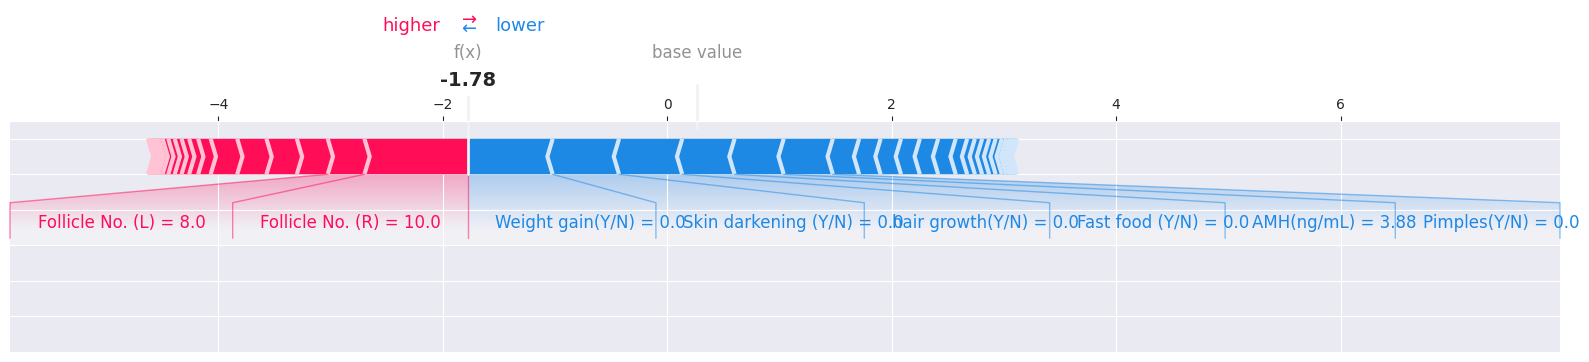

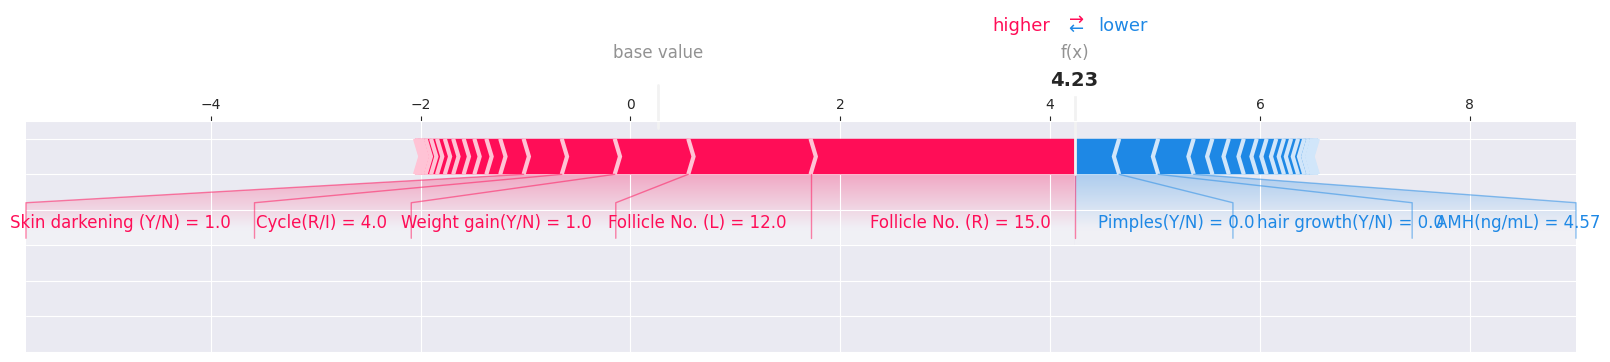

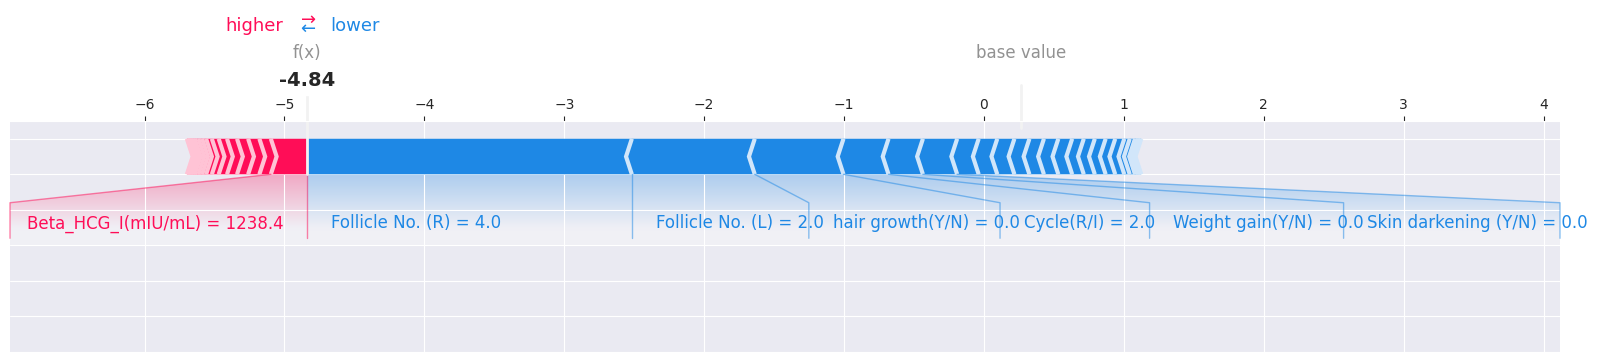

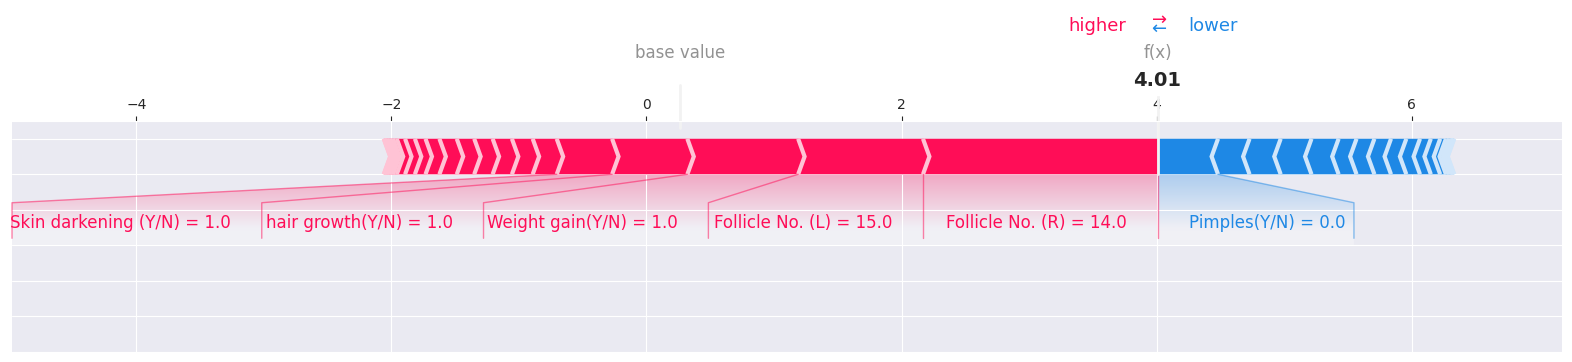

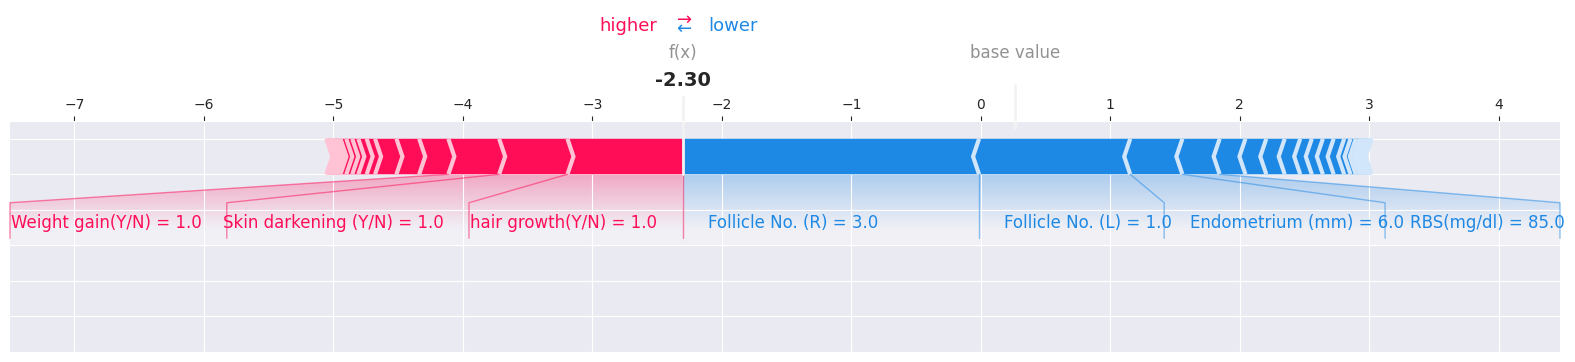

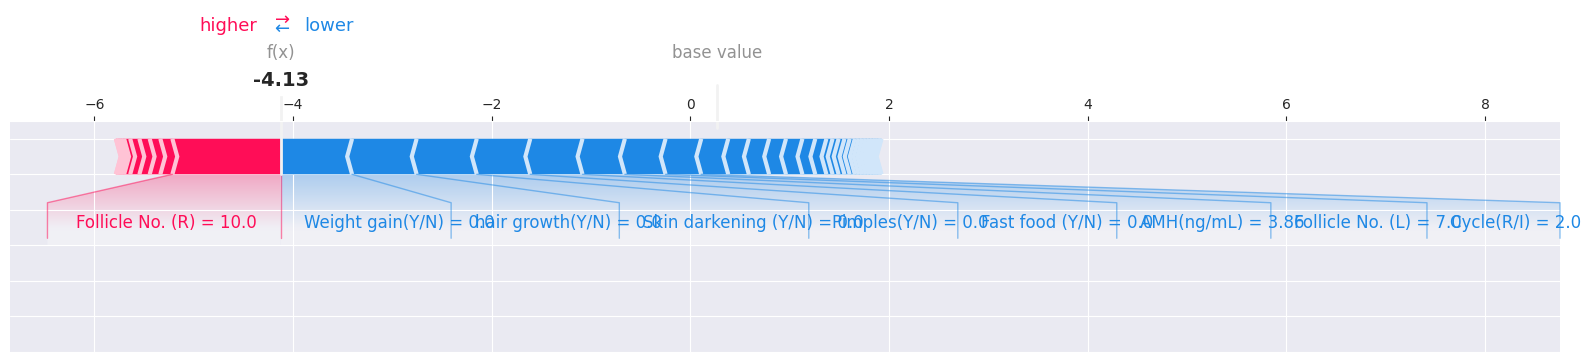

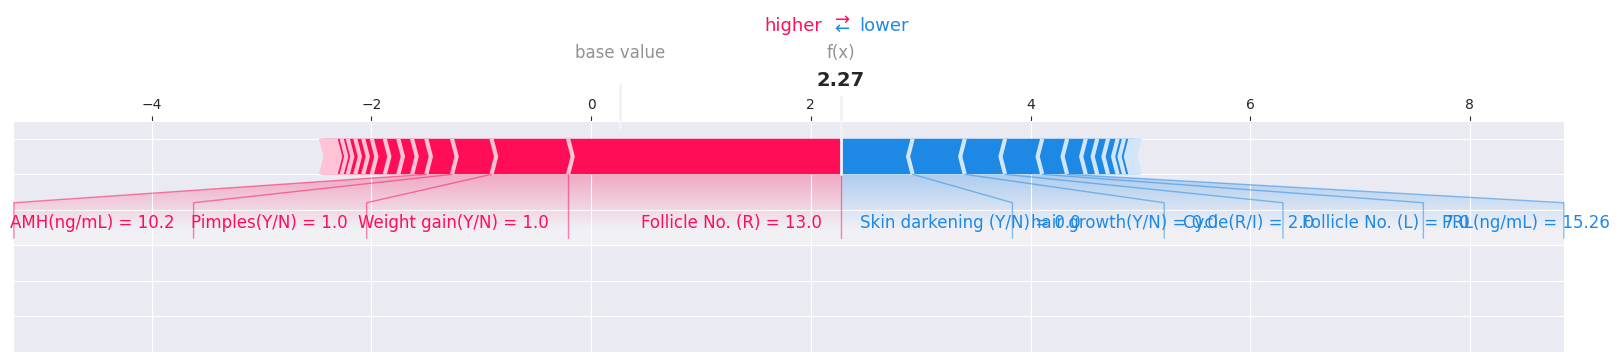

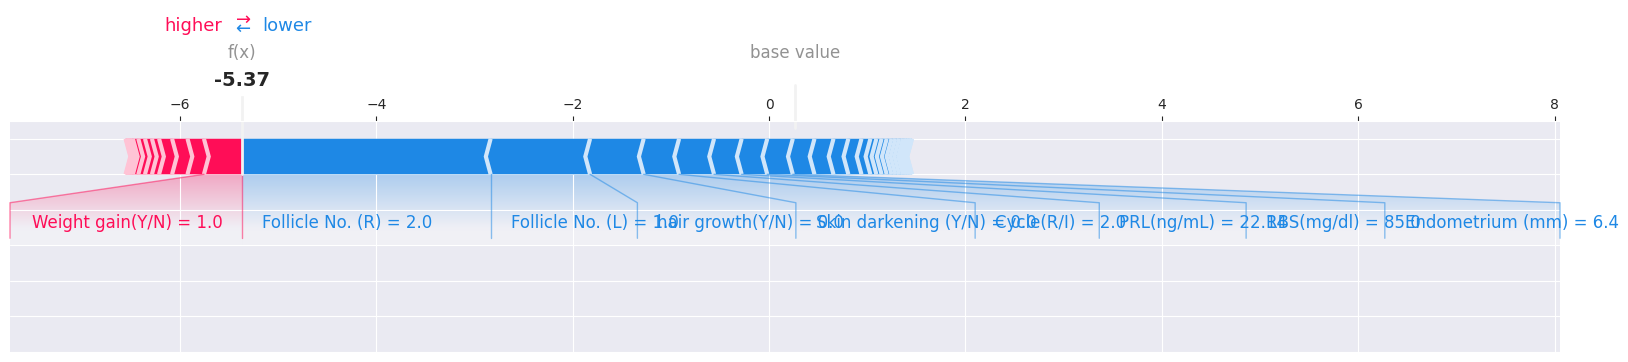

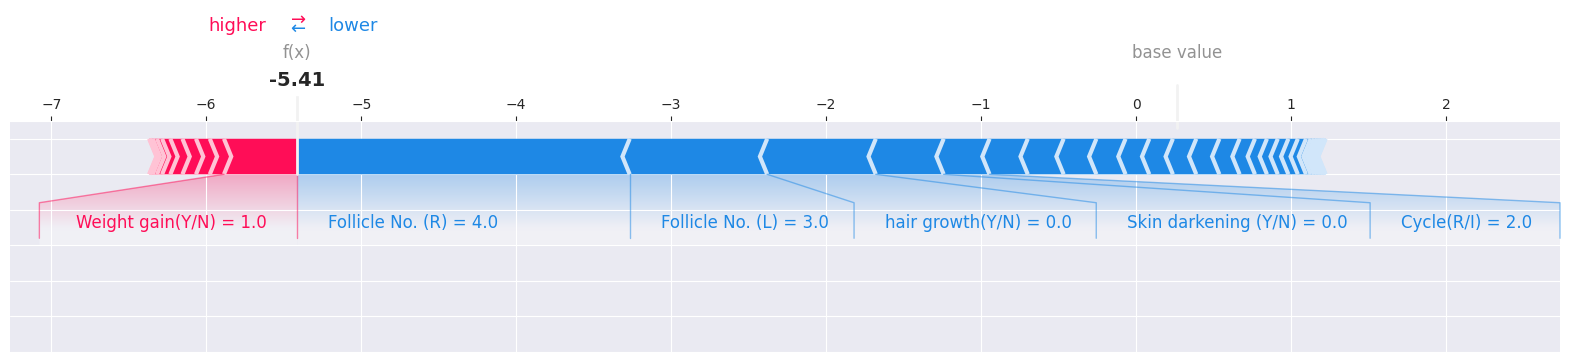

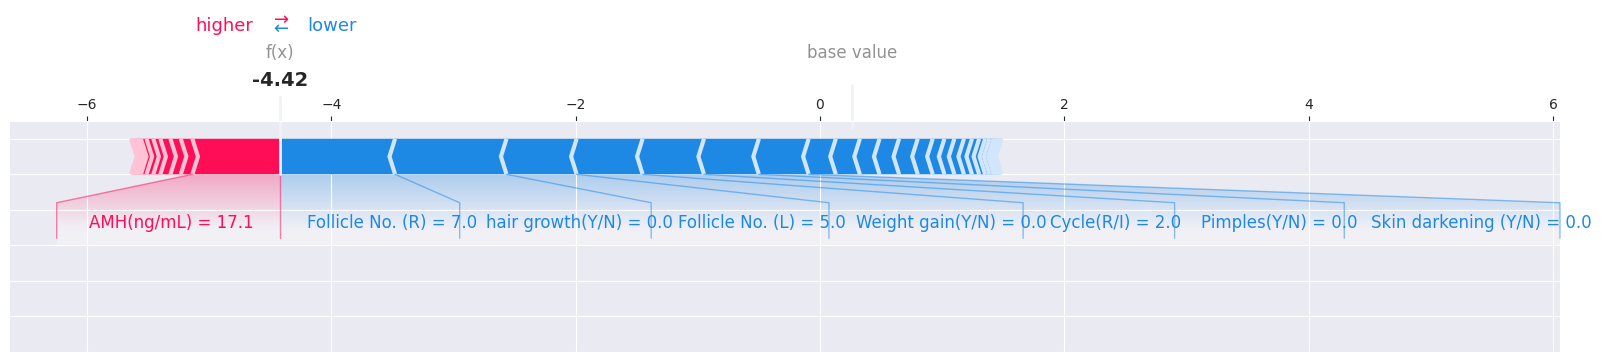

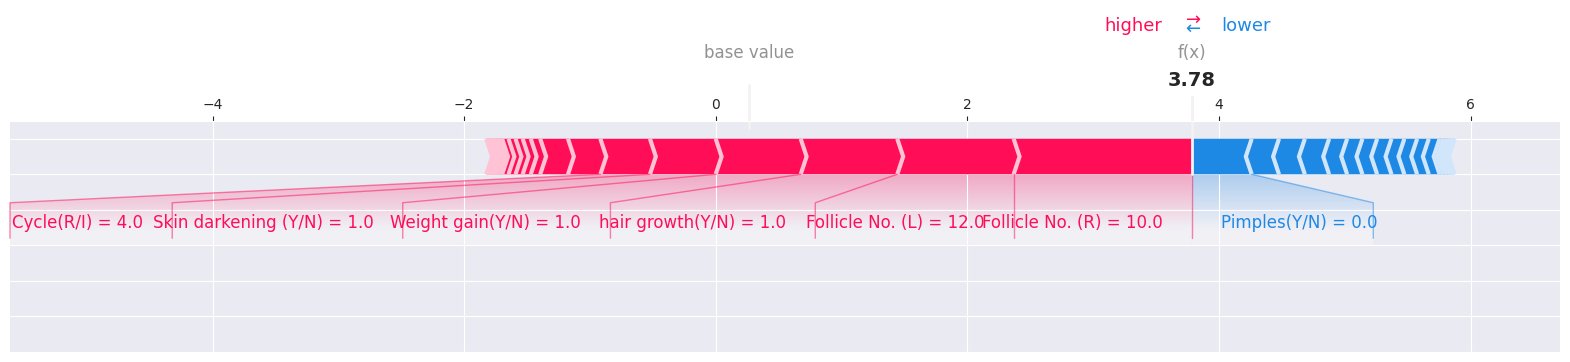

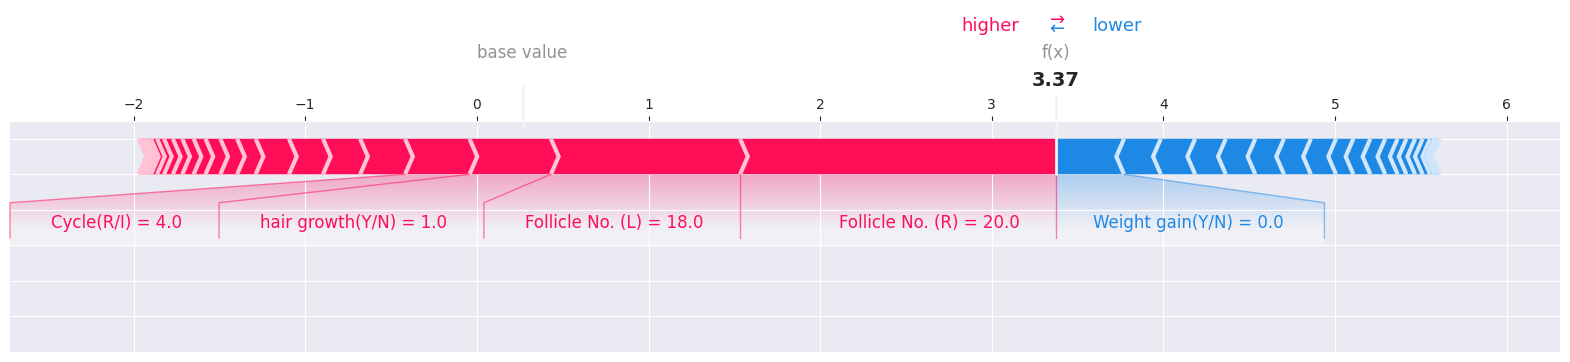

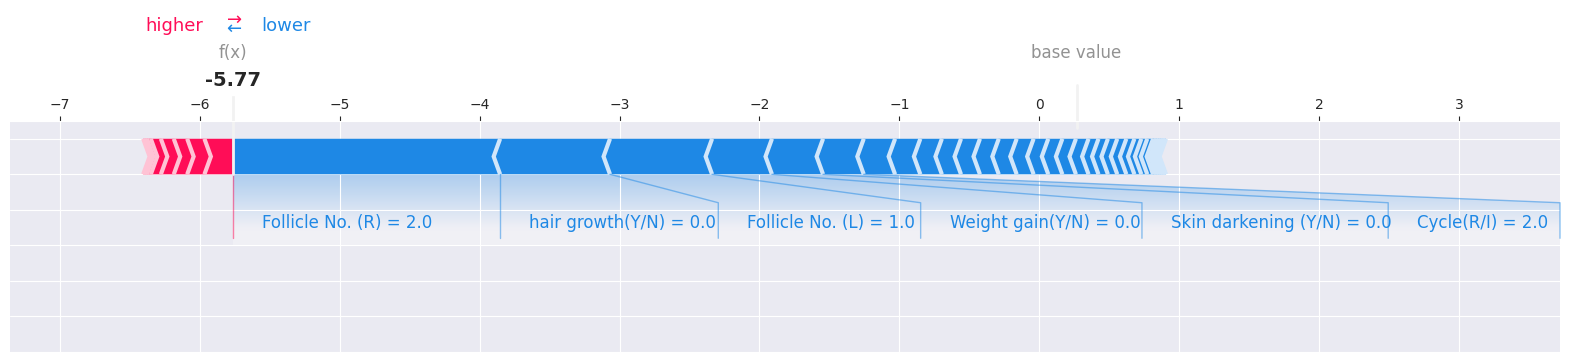

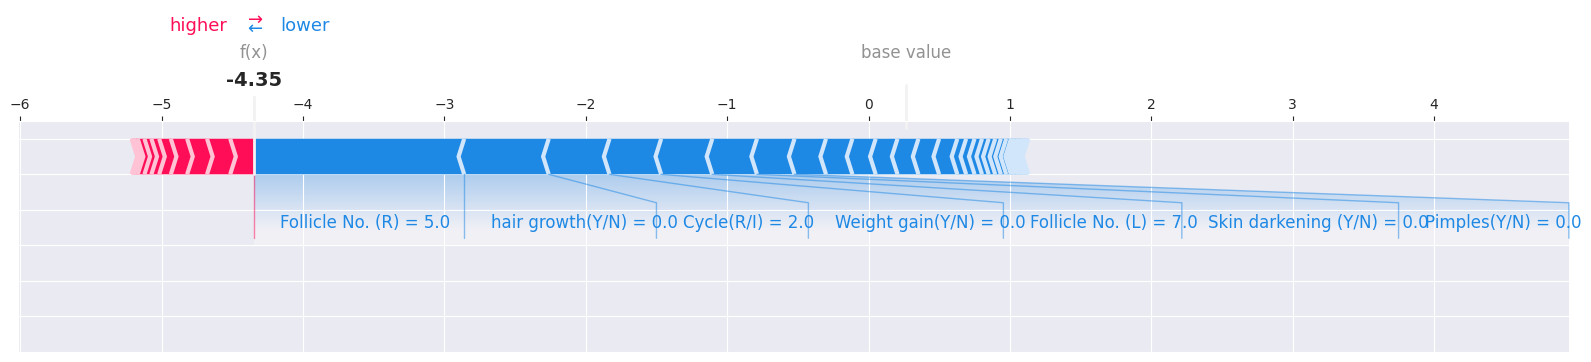

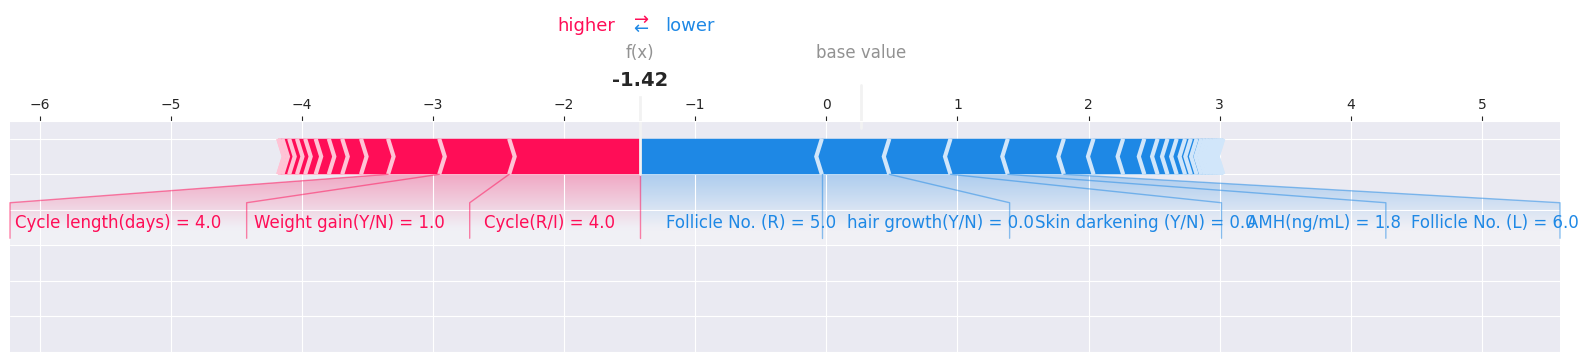

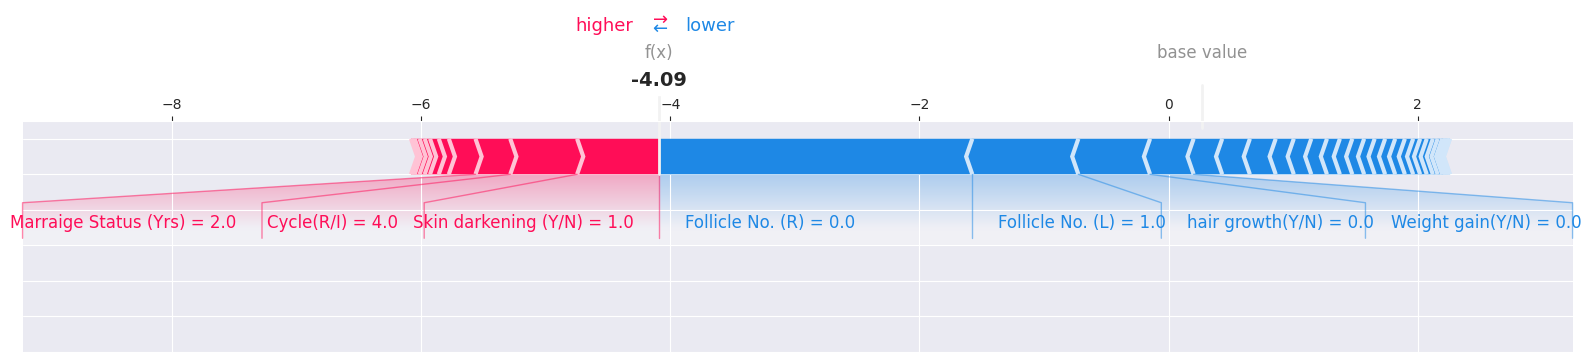

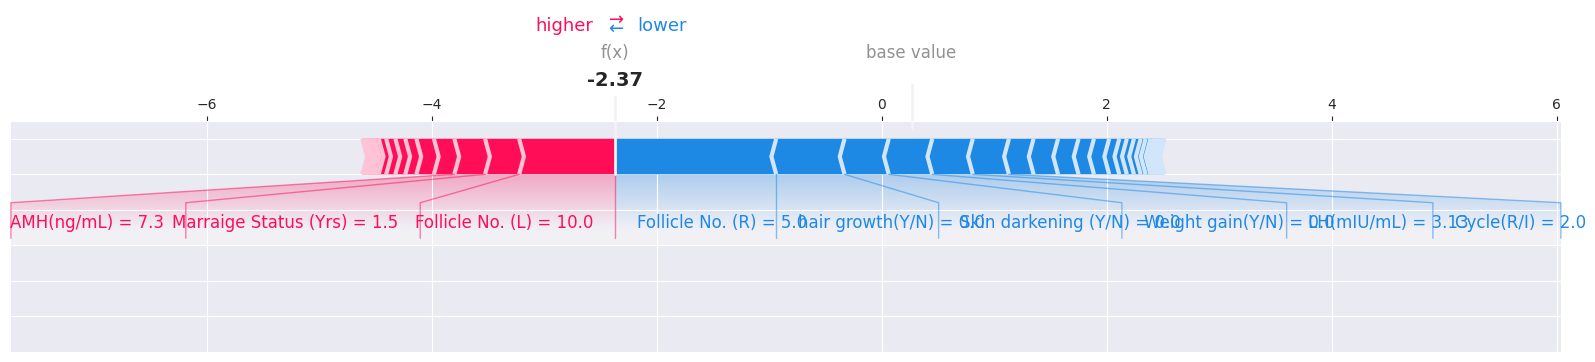

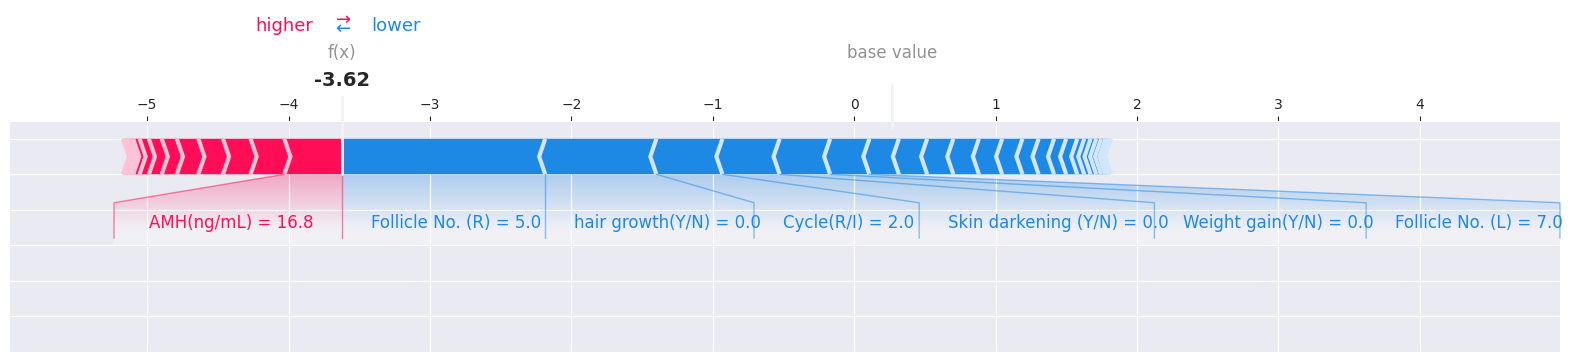

In [64]:
# shap.force_plot(explainer.expected_value, shap_values[0].values, X_test.iloc[0, :], matplotlib=True)

for i in range(20):
    shap.force_plot(explainer.expected_value, shap_values[i].values, X_test.iloc[i, :], matplotlib=True)

In [65]:
shap.force_plot(explainer.expected_value, shap_values.values, X_test)

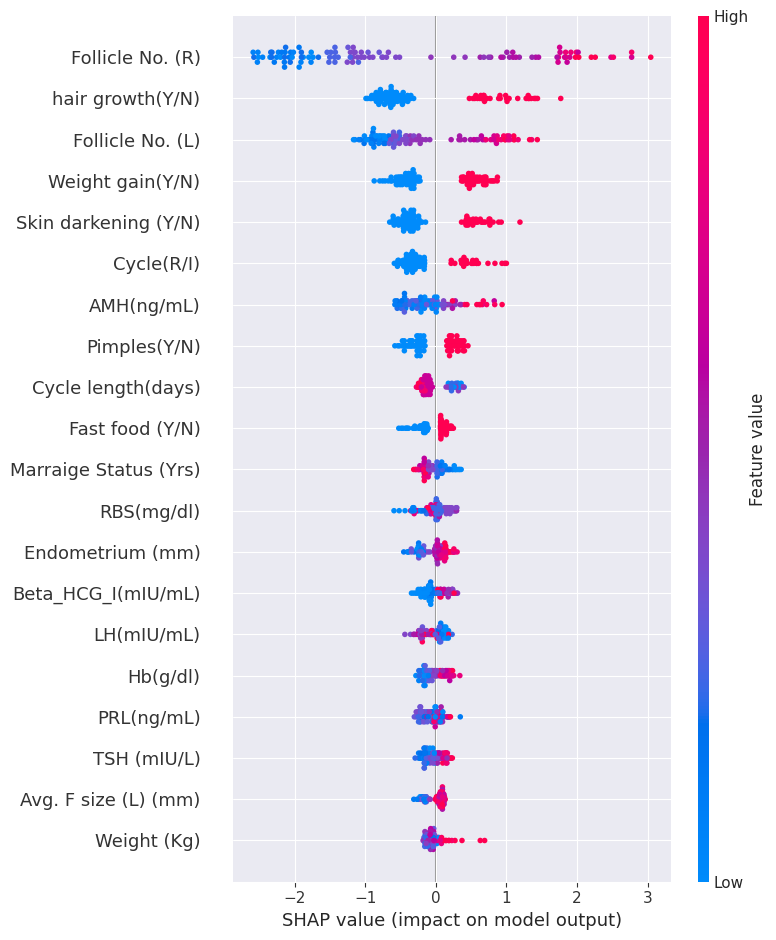

In [66]:
shap.summary_plot(shap_values, X_test)

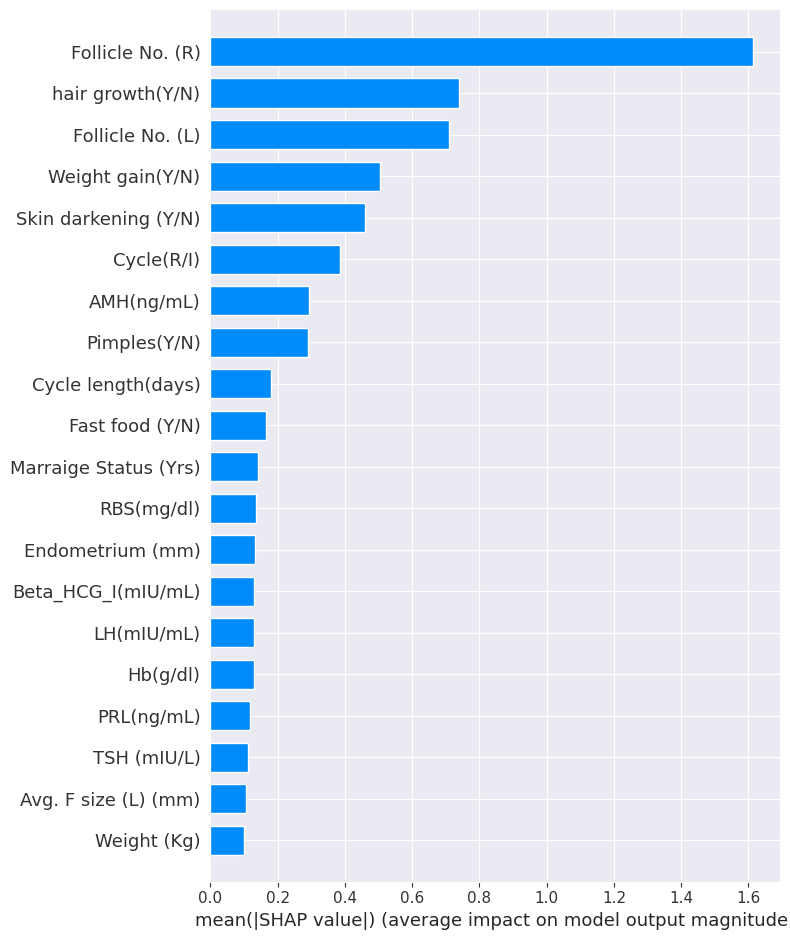

In [67]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [68]:
# Visualizes the contribution of each feature for a single prediction
shap.force_plot(explainer.expected_value, shap_values.values[0, :], X_test.iloc[0, :])

In [79]:
# Save the trained model into a pickle file
joblib.dump(model, "../data/processed/pcos_xgb_model.pkl")

['../data/processed/pcos_xgb_model.pkl']